Hola **Aron**!

Soy **Patricio Requena** 👋. Es un placer ser el revisor de tu proyecto el día de hoy!

Revisaré tu proyecto detenidamente con el objetivo de ayudarte a mejorar y perfeccionar tus habilidades. Durante mi revisión, identificaré áreas donde puedas hacer mejoras en tu código, señalando específicamente qué y cómo podrías ajustar para optimizar el rendimiento y la claridad de tu proyecto. Además, es importante para mí destacar los aspectos que has manejado excepcionalmente bien. Reconocer tus fortalezas te ayudará a entender qué técnicas y métodos están funcionando a tu favor y cómo puedes aplicarlos en futuras tareas. 

_**Recuerda que al final de este notebook encontrarás un comentario general de mi parte**_, empecemos!

Encontrarás mis comentarios dentro de cajas verdes, amarillas o rojas, ⚠️ **por favor, no muevas, modifiques o borres mis comentarios** ⚠️:


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si todo está perfecto.
</div>

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si tu código está bien pero se puede mejorar o hay algún detalle que le hace falta.
</div>

<div class="alert alert-block alert-danger">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si de pronto hace falta algo o existe algún problema con tu código o conclusiones.
</div>

Puedes responderme de esta forma:
<div class="alert alert-block alert-info">
    <b>Respuesta:</b> 

# Proyecto 13

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import KMeans

In [2]:
df = pd.read_csv('/datasets/gym_churn_us.csv')

Observar los valores del dataset

In [3]:
df.head()

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
0,1,1,1,1,0,6,1,29,14.227470,5.0,3,0.020398,0.000000,0
1,0,1,0,0,1,12,1,31,113.202938,12.0,7,1.922936,1.910244,0
2,0,1,1,0,1,1,0,28,129.448479,1.0,2,1.859098,1.736502,0
3,0,1,1,1,1,12,1,33,62.669863,12.0,2,3.205633,3.357215,0
4,1,1,1,1,1,1,0,26,198.362265,1.0,3,1.113884,1.120078,0


In [4]:
df.describe()

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,0.510250,0.845250,0.486750,0.308500,0.903500,4.681250,0.412250,29.184250,146.943728,4.322750,3.724750,1.879020,1.767052,0.265250
std,0.499957,0.361711,0.499887,0.461932,0.295313,4.549706,0.492301,3.258367,96.355602,4.191297,3.749267,0.972245,1.052906,0.441521
min,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,18.000000,0.148205,1.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,27.000000,68.868830,1.000000,1.000000,1.180875,0.963003,0.000000
50%,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,29.000000,136.220159,1.000000,3.000000,1.832768,1.719574,0.000000
75%,1.000000,1.000000,1.000000,1.000000,1.000000,6.000000,1.000000,31.000000,210.949625,6.000000,5.000000,2.536078,2.510336,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,12.000000,1.000000,41.000000,552.590740,12.000000,31.000000,6.023668,6.146783,1.000000


In [5]:
df.shape

(4000, 14)

In [6]:
df.columns

Index(['gender', 'Near_Location', 'Partner', 'Promo_friends', 'Phone',
       'Contract_period', 'Group_visits', 'Age',
       'Avg_additional_charges_total', 'Month_to_end_contract', 'Lifetime',
       'Avg_class_frequency_total', 'Avg_class_frequency_current_month',
       'Churn'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   gender                             4000 non-null   int64  
 1   Near_Location                      4000 non-null   int64  
 2   Partner                            4000 non-null   int64  
 3   Promo_friends                      4000 non-null   int64  
 4   Phone                              4000 non-null   int64  
 5   Contract_period                    4000 non-null   int64  
 6   Group_visits                       4000 non-null   int64  
 7   Age                                4000 non-null   int64  
 8   Avg_additional_charges_total       4000 non-null   float64
 9   Month_to_end_contract              4000 non-null   float64
 10  Lifetime                           4000 non-null   int64  
 11  Avg_class_frequency_total          4000 non-null   float

Observar los valores medios

In [8]:
df.groupby('Churn').mean()

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month
Churn,,,,,,,,,,,,,
0,0.510037,0.873086,0.534195,0.353522,0.903709,5.747193,0.464103,29.976523,158.445715,5.283089,4.711807,2.024876,2.027882
1,0.510839,0.768143,0.355325,0.183789,0.902922,1.728558,0.268615,26.989632,115.082899,1.662582,0.990575,1.474995,1.044546


<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Correcto, analizaste muy bien de manera inicial los datos con lo que trabajarás
</div>

# Trazar Histogramas

In [9]:
sns.set(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.figsize"] = (12,6)

In [10]:
categorical_cols = [
    'gender',
    'Near_Location',
    'Partner',
    'Promo_friends',
    'Phone',
    'Contract_period',
    'Group_visits'
]

In [11]:
numerical_cols = [
    'Age',
    'Lifetime',
    'Month_to_end_contract',
    'Avg_class_frequency_total',
    'Avg_class_frequency_current_month',
    'Avg_additional_charges_total'
]

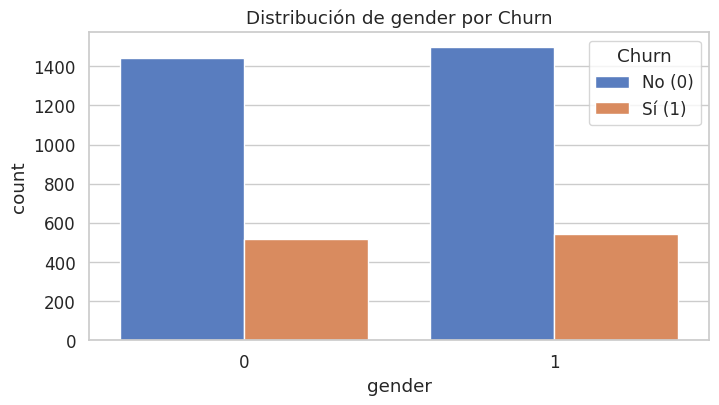

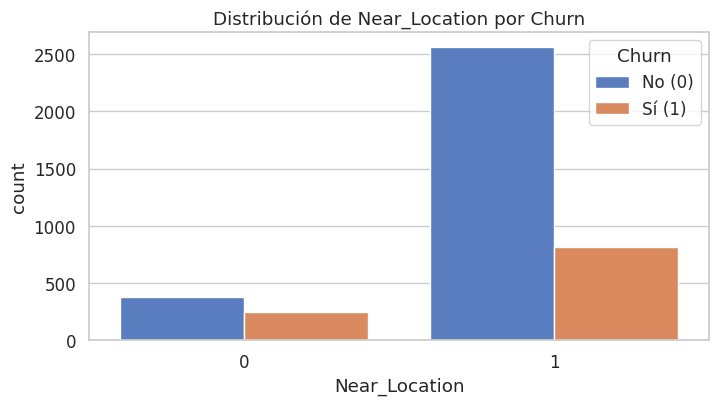

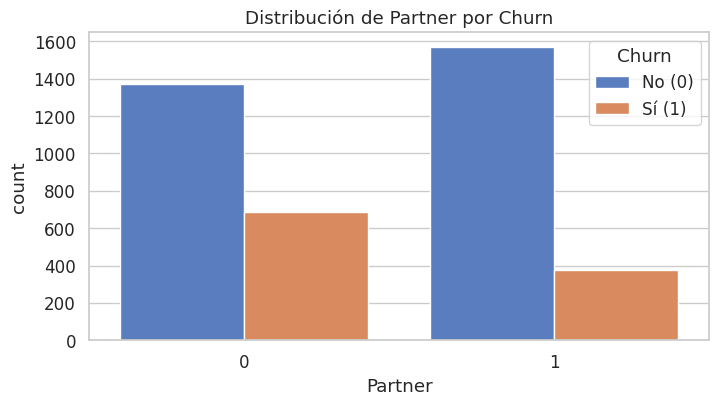

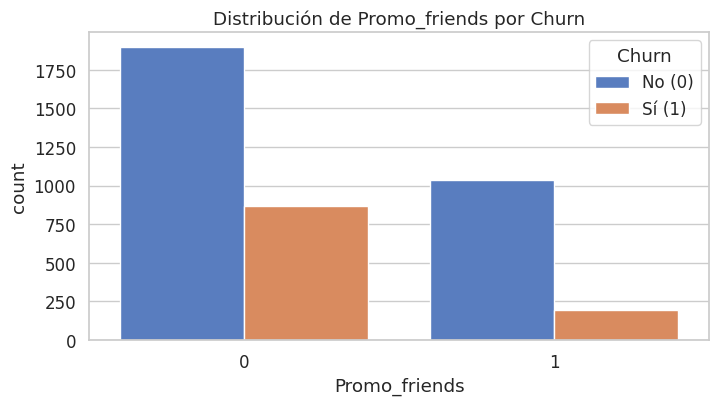

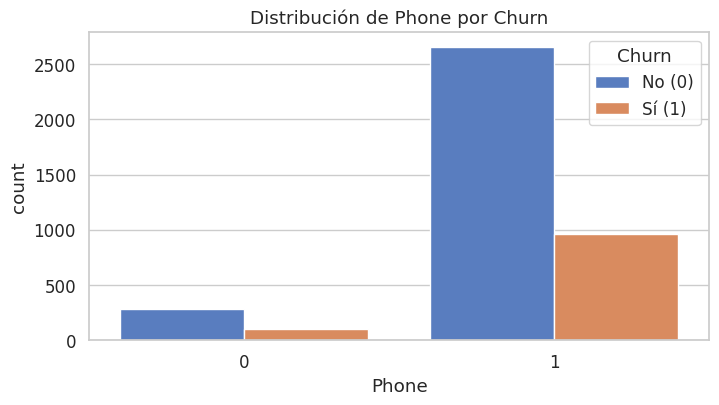

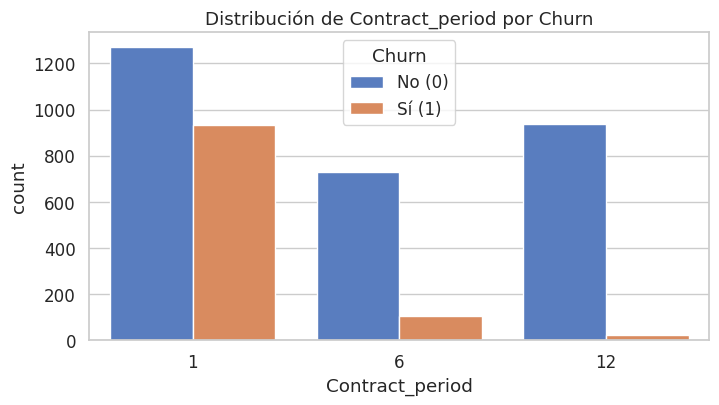

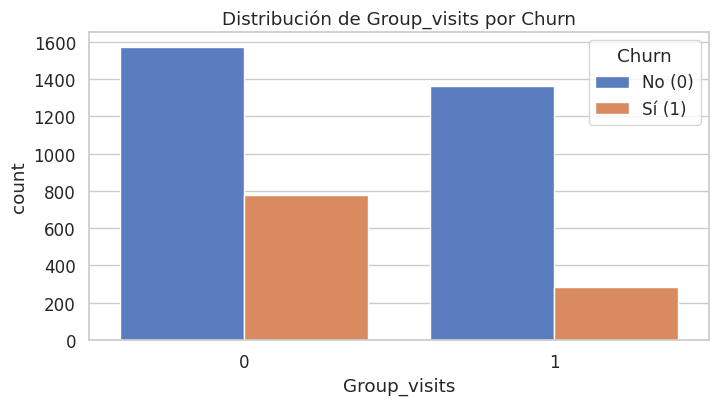

In [12]:
for col in categorical_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(data=df, x=col, hue="Churn")
    plt.title(f"Distribución de {col} por Churn")
    plt.legend(title="Churn", labels=["No (0)", "Sí (1)"])
    plt.show()

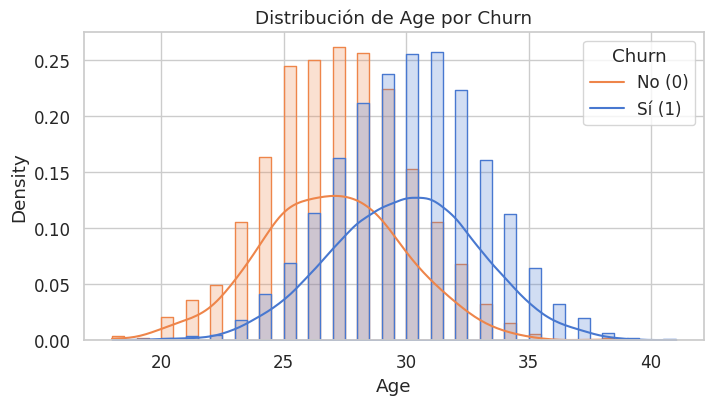

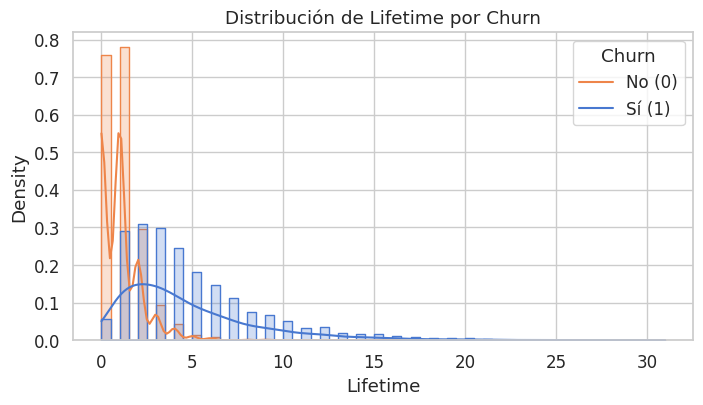

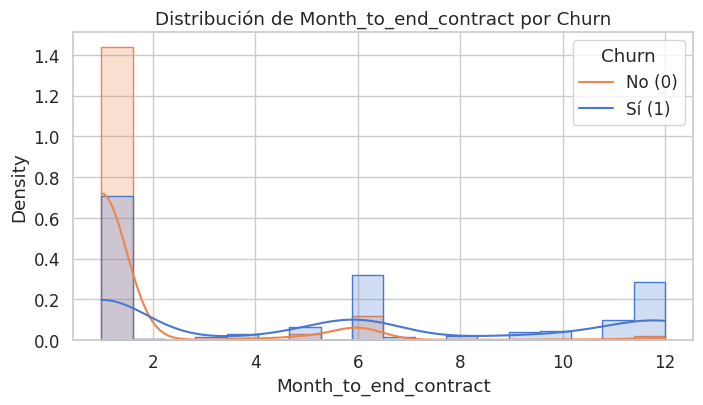

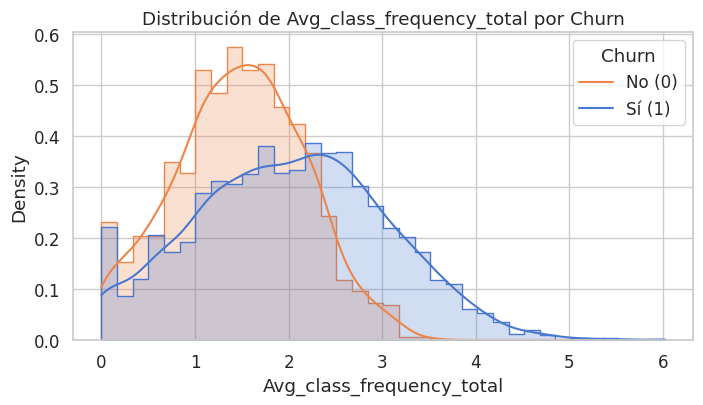

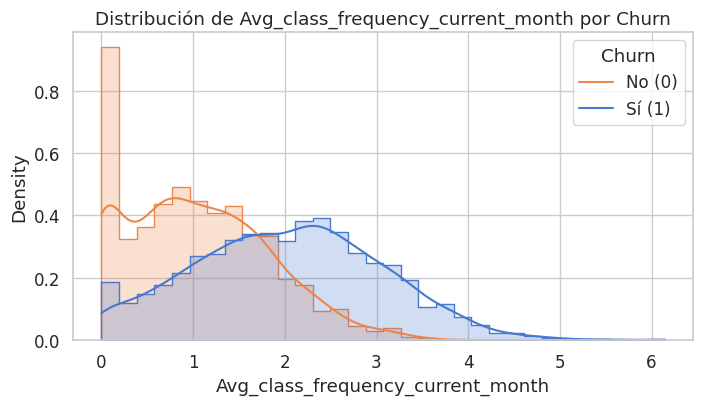

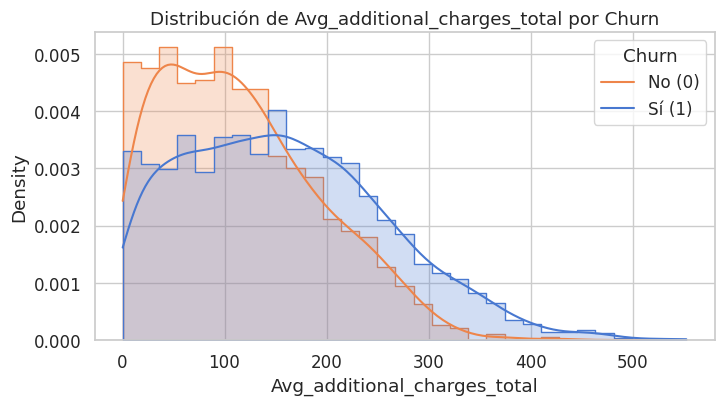

In [13]:
for col in numerical_cols:
    plt.figure(figsize=(8,4))
    sns.histplot(
        data=df, 
        x=col, 
        hue="Churn", 
        kde=True, 
        element="step", 
        stat="density", 
        common_norm=False
    )
    plt.title(f"Distribución de {col} por Churn")
    plt.legend(title="Churn", labels=["No (0)", "Sí (1)"])
    plt.show()

# Observaciones 

de los puntos mas importantes es que entre menos tiempo de contrato tengas en el gym mas probable es que haya churn, pero esto tambien puede considerarse que si pagaste una membresia de larga duracion no estamos considerando la idea de que la paga y no vaya, de igualmanera es un cliente muy interesante para ofrecerle promociones a largoplazo. los jovenes presentan una mayor cantidad o probbailidad de chrun pero no es tan marcada. un punto interesante es en los partner emprezas que tienen convenios con el gym sus lcientes relacionados a esta metrica presentan un menor churn. uno muy clasico o sencillo de saber el porque es que las personas que viven mas cerca del gym tienen menos churn.

<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Muy bien hecho! Estas gráficas son muy claras para mostrar las diferencias entre cada variable de tu dataset
</div>

# matriz de correlacion

In [14]:
corr_matrix = df.corr()

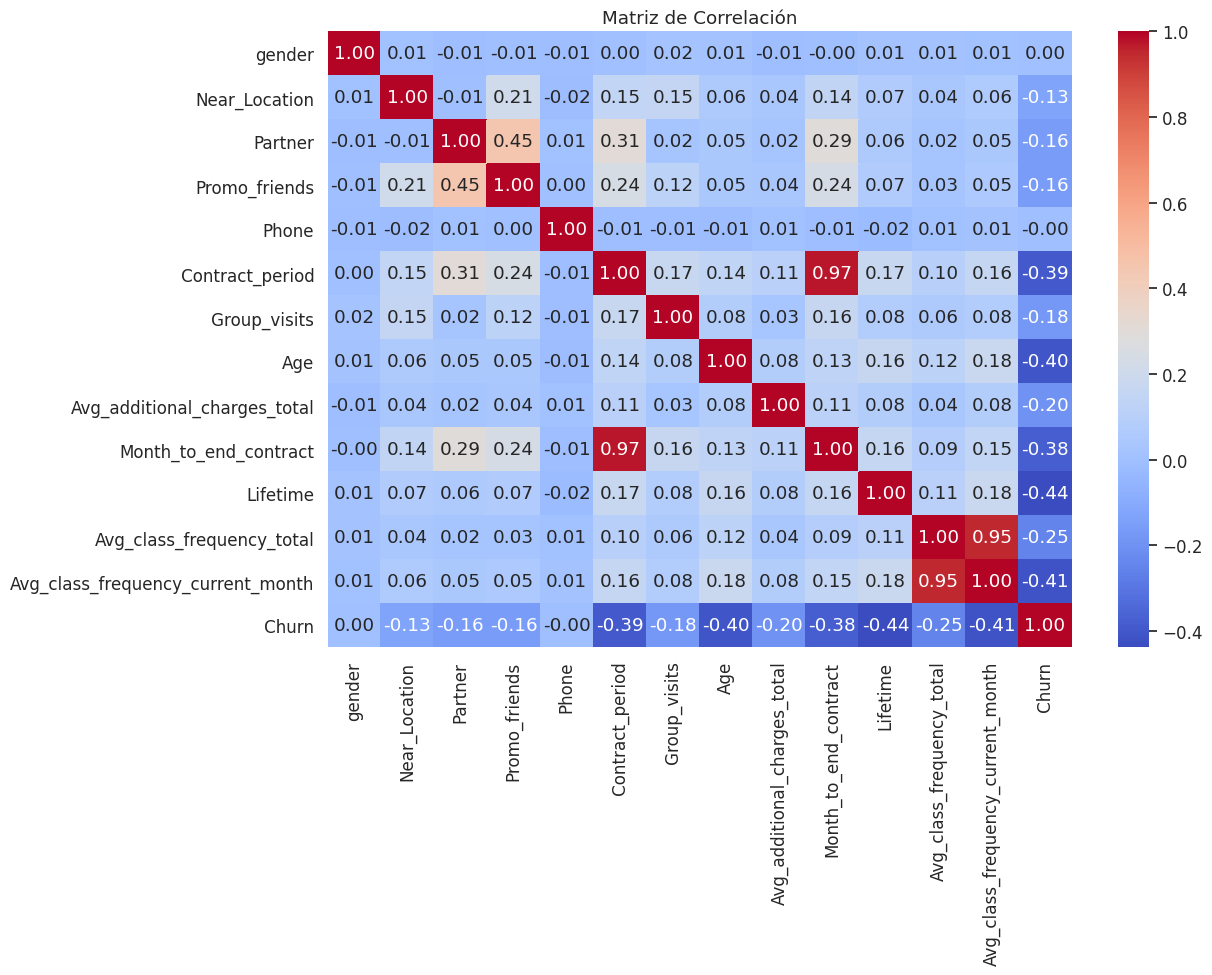

In [15]:
plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Matriz de Correlación")
plt.show()

In [16]:
print(corr_matrix["Churn"].sort_values(ascending=False))


Churn                                1.000000
gender                               0.000708
Phone                               -0.001177
Near_Location                       -0.128098
Partner                             -0.157986
Promo_friends                       -0.162233
Group_visits                        -0.175325
Avg_additional_charges_total        -0.198697
Avg_class_frequency_total           -0.249715
Month_to_end_contract               -0.381393
Contract_period                     -0.389984
Age                                 -0.404735
Avg_class_frequency_current_month   -0.412348
Lifetime                            -0.438220
Name: Churn, dtype: float64


# observaciones

como lo comentabamos las personas con periodos largos insritos tienen menos probabilidad de salirse del gym y tambien las personas que van constantmeente a diario tienen menos probabilidad de tener churn o abandonar. un punto interesante es los cargos adicionales o compras extras dentro del gym ese tipo de clientes los vuelven mas leales al hacer ese tipo de compras ya que sienten una conexion o comodidad en el lugar

<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Muy bien mostrada la matriz de correlación! Solo ten en cuenta que no siempre correlación significa causalidad, puede que en algunos casos tengas variables altamente correlacionadas pero no necesariamente son causa una de la otra

# Construir un modelo para predecir la cancelación de usuarios

In [17]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [19]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [20]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

y_pred_lr = log_reg.predict(X_test_scaled)
y_proba_lr = log_reg.predict_proba(X_test_scaled)[:,1]

In [21]:
print("Regresión Logística")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("ROC AUC:", roc_auc_score(y_test, y_proba_lr))
print(classification_report(y_test, y_pred_lr))

Regresión Logística
Accuracy: 0.925
ROC AUC: 0.9774499422410474
              precision    recall  f1-score   support

           0       0.94      0.96      0.95       588
           1       0.88      0.83      0.85       212

    accuracy                           0.93       800
   macro avg       0.91      0.89      0.90       800
weighted avg       0.92      0.93      0.92       800



In [22]:
rf = RandomForestClassifier(
    n_estimators=200, random_state=42, class_weight="balanced"
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:,1]

In [23]:
print("\n Random Forest")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("ROC AUC:", roc_auc_score(y_test, y_proba_rf))
print(classification_report(y_test, y_pred_rf))


 Random Forest
Accuracy: 0.9175
ROC AUC: 0.9671175073803107
              precision    recall  f1-score   support

           0       0.93      0.96      0.94       588
           1       0.87      0.81      0.84       212

    accuracy                           0.92       800
   macro avg       0.90      0.88      0.89       800
weighted avg       0.92      0.92      0.92       800



In [24]:

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

y_pred_lr = log_reg.predict(X_test_scaled)

acc_lr = accuracy_score(y_test, y_pred_lr)
prec_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)

In [25]:
rf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced")
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

acc_rf = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)

In [26]:
print("Resultados de Validación")
print("\n--- Regresión Logística ---")
print(f"Accuracy:  {acc_lr:.3f}")
print(f"Precisión: {prec_lr:.3f}")
print(f"Recall:    {recall_lr:.3f}")

print("\n--- Random Forest ---")
print(f"Accuracy:  {acc_rf:.3f}")
print(f"Precisión: {prec_rf:.3f}")
print(f"Recall:    {recall_rf:.3f}")

Resultados de Validación

--- Regresión Logística ---
Accuracy:  0.925
Precisión: 0.880
Recall:    0.830

--- Random Forest ---
Accuracy:  0.917
Precisión: 0.872
Recall:    0.807


In [27]:
if acc_rf > acc_lr:
    print("\n Random Forest tuvo mejor exactitud.")
else:
    print("\n Regresión Logística tuvo mejor exactitud.")

if prec_rf > prec_lr:
    print(" Random Forest tuvo mejor precisión.")
else:
    print(" Regresión Logística tuvo mejor precisión.")

if recall_rf > recall_lr:
    print(" Random Forest tuvo mejor recall.")
else:
    print(" Regresión Logística tuvo mejor recall.")


 Regresión Logística tuvo mejor exactitud.
 Regresión Logística tuvo mejor precisión.
 Regresión Logística tuvo mejor recall.


<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Muy buen trabajo! Obtuviste resultados muy buenos en el entrenamiento de tus modelos y realizaste el análisis adecuado a partir de los mismos
</div>

# Crear clústeres de usuarios/as

In [28]:
X = df.drop("Churn", axis=1)

In [29]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [30]:
linked = linkage(X_scaled, method='ward')


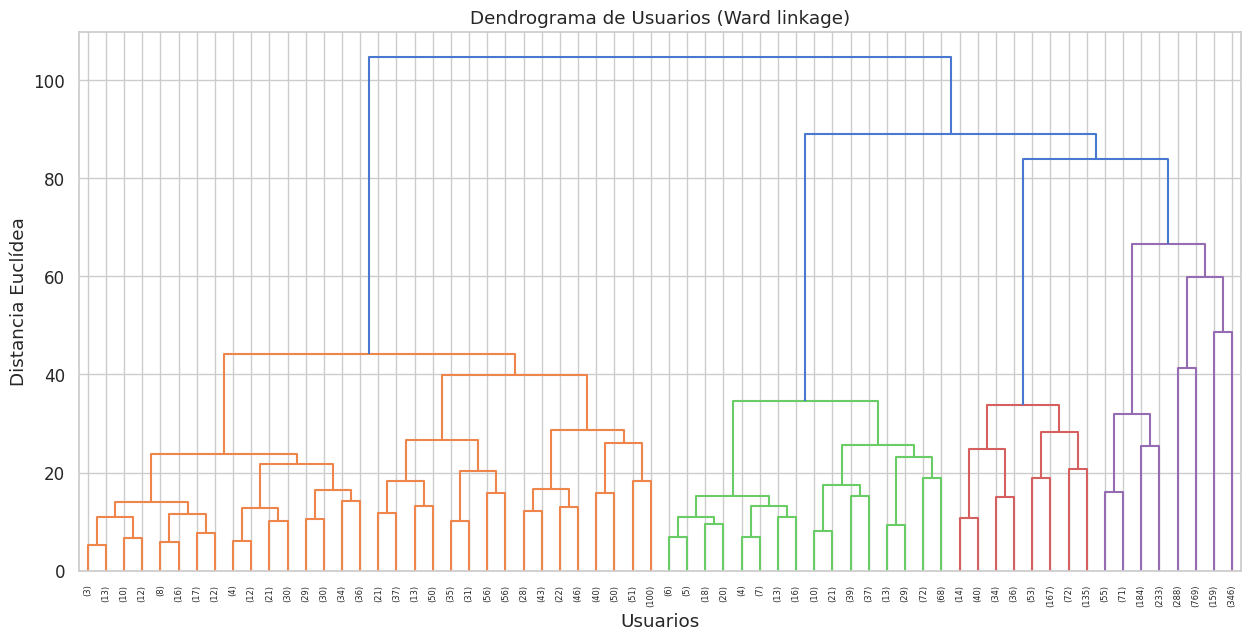

In [31]:
plt.figure(figsize=(15, 7))
dendrogram(linked, truncate_mode="level", p=5)  
plt.title("Dendrograma de Usuarios (Ward linkage)")
plt.xlabel("Usuarios")
plt.ylabel("Distancia Euclídea")
plt.show()

In [32]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

In [33]:
df["Cluster"] = clusters

In [34]:
cluster_means = df.groupby("Cluster").mean(numeric_only=True)
print(cluster_means)

           gender  Near_Location   Partner  Promo_friends  Phone  \
Cluster                                                            
0        0.502370       0.949447  0.829384       0.998420    1.0   
1        0.554556       0.849269  0.263217       0.052868    1.0   
2        0.499422       0.937572  0.737572       0.478613    1.0   
3        0.485738       0.718011  0.299919       0.018745    1.0   
4        0.523316       0.862694  0.471503       0.305699    0.0   

         Contract_period  Group_visits        Age  \
Cluster                                             
0               3.097946      0.448657  29.104265   
1               2.606299      0.436445  30.008999   
2              11.854335      0.546821  29.905202   
3               1.914425      0.276284  28.083945   
4               4.777202      0.427461  29.297927   

         Avg_additional_charges_total  Month_to_end_contract  Lifetime  \
Cluster                                                                  
0  

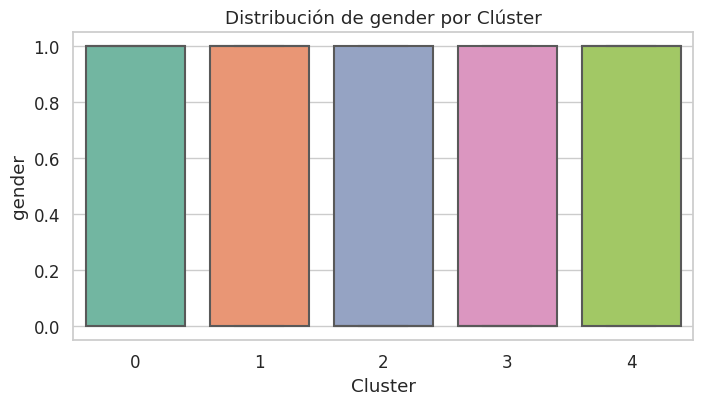

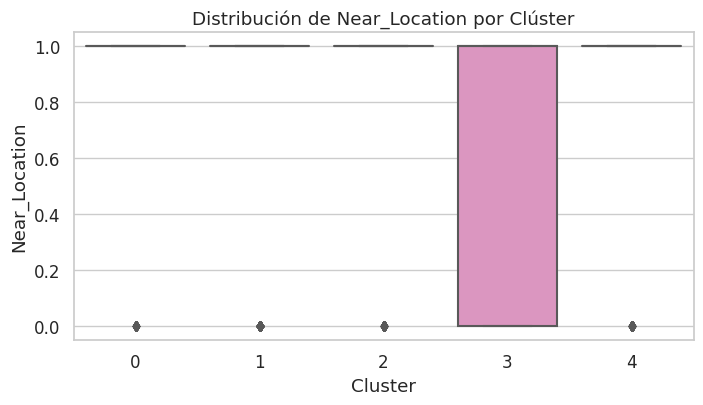

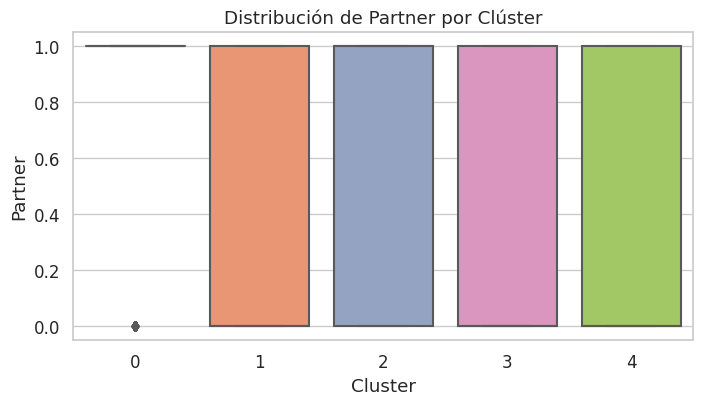

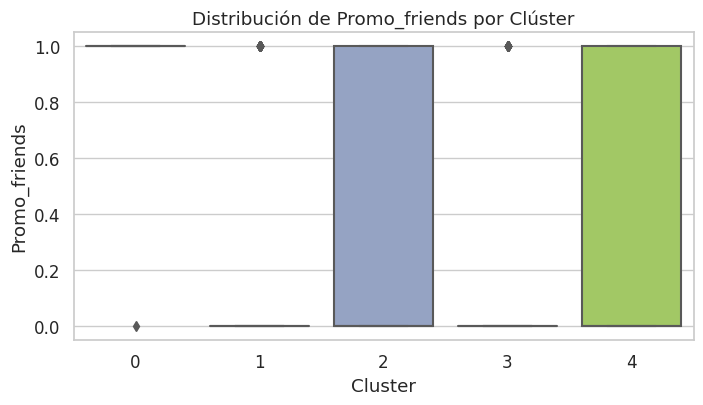

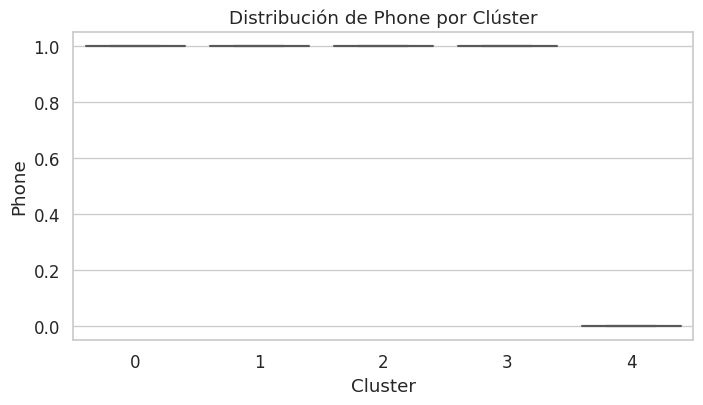

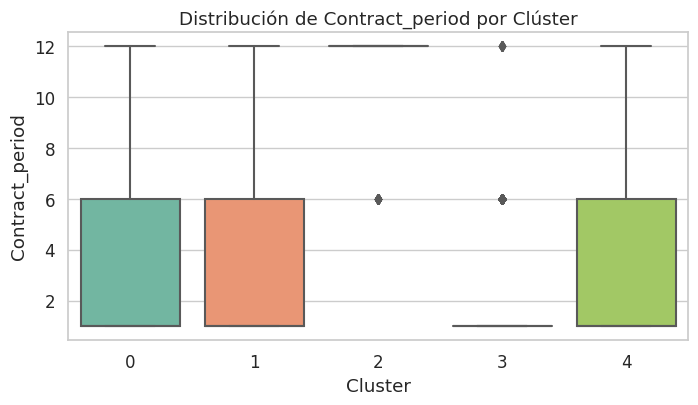

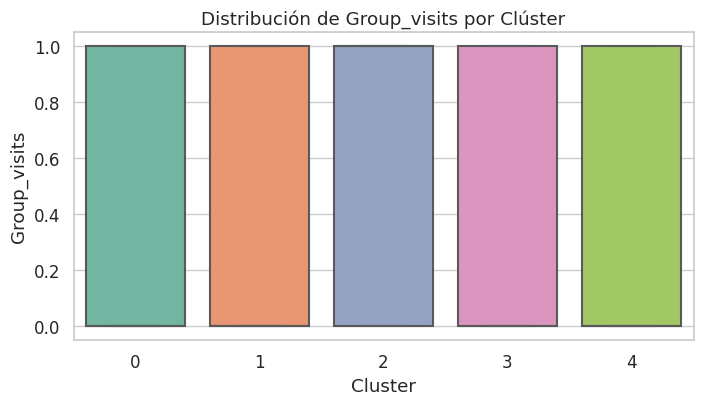

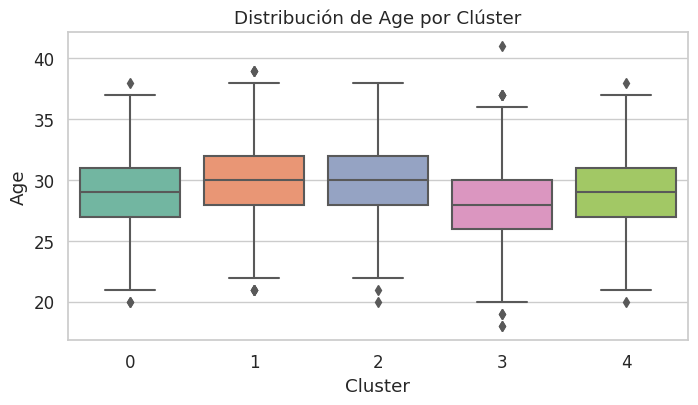

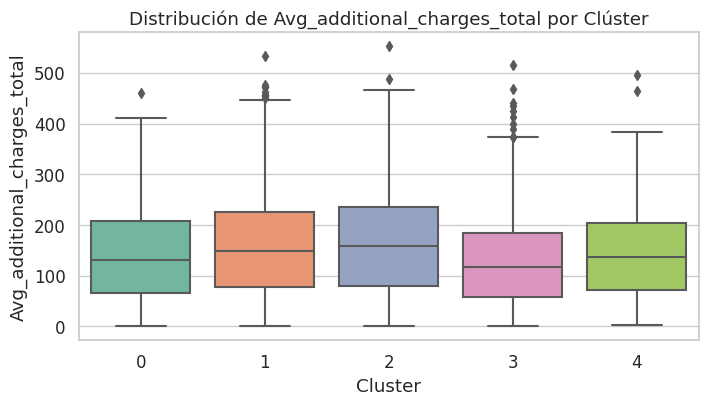

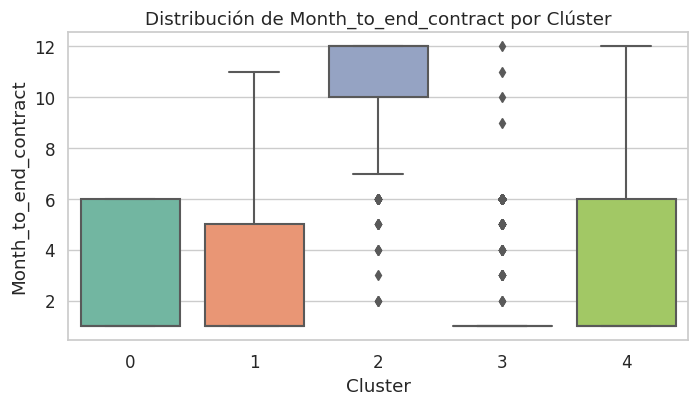

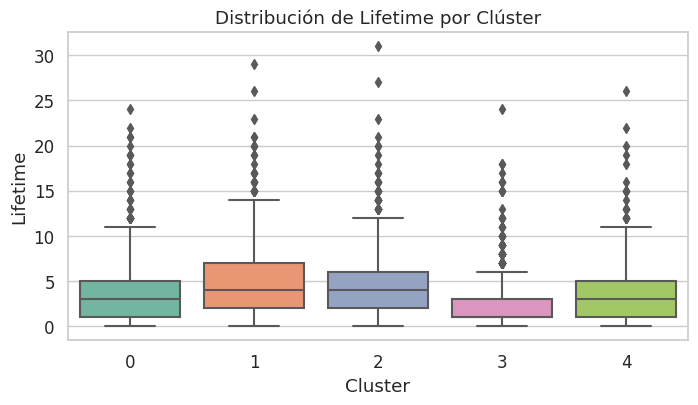

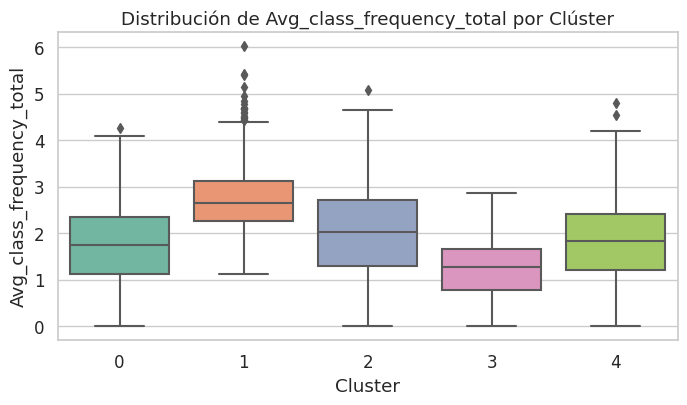

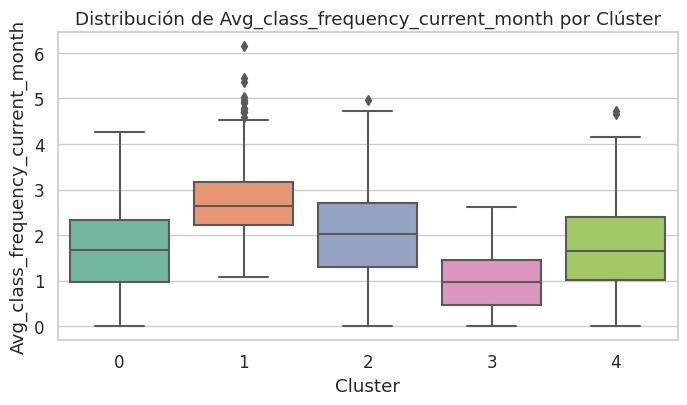

In [35]:
for col in X.columns:
    plt.figure(figsize=(8,4))
    sns.boxplot(data=df, x="Cluster", y=col, palette="Set2")
    plt.title(f"Distribución de {col} por Clúster")
    plt.show()

# Tasa de cancelacion

In [36]:
churn_rate = df.groupby("Cluster")["Churn"].mean().sort_values(ascending=False)

print("Tasa de cancelación por clúster:")
print(churn_rate)

Tasa de cancelación por clúster:
Cluster
3    0.572942
4    0.266839
0    0.246445
1    0.089989
2    0.021965
Name: Churn, dtype: float64


# Observaciones Clusters

Cluster0 son clientes con poca actividad o nuevos, no tienen mucho gasto extra aparte de la mensualidad y tinen poca retencion

Cluster1 son clientes a largo plazo y algo mas fieles, tienen alta frecuencia de visitas y suelen tener contratos de medio año en adelante

Cluster 2 clientes sociales y activos la diferencia que tienen este grupo a los anteriores es su alta actividdad en griupos dentro del gym como yoga, spinning etc.

Cluster 3 clientes premium o clientes que tienen un alto consumo dentro del gym y consumo en sus complementos como cafeteria o suplementos.

Cluster 4 clientes de convenios suelen vivir cerca o tener un convenio con alguna empresa y que estaran en el gym mientras dure el convenio y no generan gran ganancia a la empresa pero son potencialmente cliente que se puede convertir

Se tiene un balance en los cluster 2 grupos de alto riesgo(clientes que no se quedan por mucho tiempo o poca actividad) y 2 grupos de alto beneficios (como los de alta actividad o premium clientes que se mantienen fieles y les gusta el servicio)

<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Bien hecho! Se nota claramente la segmentación entre los diferentes grupos ya que tienen un churn rate diferente
</div>

# Conclusiones finales 

Anteriormente hablabamos 2 grupos con alto riesgo y 2 de alto beneficio. si lo que queremos es que los grupos de alto riesgo sean rentables lo mejor es introducir promociones de primer ingreso que tengan un valor por 'x' cantidad de meses que pegandolo todo junto vuelva rentable aunque ese cliente de baja actividad o baja fidelidad se vuelva rentable aunque no vaya constentemente. 

 Mantener una media constante de clientes premium y clientes de alta calidad  es la prioridad. si, es verdad pero lograr que muchos clientes de baja actividad pagen por ofertas por mas meses mantienes una buena cantidad de dinero moviendose y la posibilidad de que algun % de esos clientes que estan inciciando se conviertan a clientes de alta actividad o premium por los beneficios que pueden obtener al probar el programa o servicio por mas tiempo e incluso si dejan de ir o abandonan habran sido clientes que dfueron rentables. 

¿Pero como logramos esto?
Bueno poneindo la membresia por 1 mes mas cara que pagar 3 o 6 meses en conjunto que individualmente por ejemplo: 1 mes 1000 pesos pero 3 meses 2500 o 6 meses por 4500 , haces que el cliente se pregunte si un mes es lo correcto por pagar y ve con mejores ojos el adquirir una membresia por mas tiempo.

<div class="alert alert-block alert-success">
<b>Comentario general (1ra Iteracion)</b> <a class=“tocSkip”></a>

Muy buen trabajo, manejaste muy bien los datos previo al entrenamiento de tus modelos y analizaste muy bien los resultados.
    
Las conclusiones en cada sección quedaron impecables dejando un proceso de análisis súper claro de inicio a fin, un buen análisis siempre debe venir acompañado de recomendaciones que ayuden a la toma de decisiones que en este caso haz planteado sugerencias muy buenas en cuanto a los diferentes tipos de usuarios obtenidos.
    
    
Saludos!
</div>